# RVF HYBRID MODEL — SYMBOL DICTIONARY / GLOSSARY

---

## TIME
- **t** : current simulation day (integer)
- **days** : total number of simulated days

---

## RAIN
- **rain[t]** : rainfall amount on day *t*
- **rain_today** : rainfall on the current day

---

## HOSTS (INDIVIDUAL-BASED MODEL — IBM)

Each host represents **one animal** (e.g., cow).

- **Nh** : total number of hosts (animals)
- **states** : array storing disease state of each host  
  - `"S"` = Susceptible (healthy)  
  - `"E"` = Exposed (infected, not infectious)  
  - `"I"` = Infectious  
  - `"R"` = Recovered  

- **days_in_state** : number of days a host has spent in its current state

### Host counts (derived daily)
- **Sh** : number of susceptible hosts
- **Eh** : number of exposed hosts
- **Ih** : number of infectious hosts
- **Rh** : number of recovered hosts

- **new_inf_h[t]** : number of new host infections on day *t*

- **latent_days** : average days from **E → I** in hosts
- **infectious_days** : average days from **I → R** in hosts

---

## VECTORS (MOSQUITOES — ODE STYLE)

Mosquitoes are **not modeled individually**; we track **population counts**.

- **Sv** : number of susceptible mosquitoes
- **Ev** : number of exposed mosquitoes
- **Iv** : number of infectious mosquitoes
- **Nv** : total mosquitoes = `Sv + Ev + Iv`

---

## PARAMETERS (BIOLOGICAL MEANINGS)

- **b** : average number of bites per mosquito per day
- **p_vh** : probability an infectious mosquito infects a host per bite
- **p_hv** : probability a mosquito becomes infected after biting an infectious host
- **mu** : daily mosquito death fraction
- **sigma** : daily fraction of exposed mosquitoes becoming infectious
- **alpha** : scaling factor linking rainfall to new mosquito emergence

---

## FORCE OF INFECTION (LINKING IBM ↔ ODE)

- **lambda_h** : infection pressure on hosts from mosquitoes  
  *(higher lambda_h → more hosts infected today)*

- **lambda_v** : infection pressure on mosquitoes from hosts

---

## OBSERVATION (SURVEILLANCE)

Observed cases are a **noisy fraction of true infections**  
*(not yet used in the simplified notebook).*


# Imports + setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

Fake rainfall (you can replace later with real data)

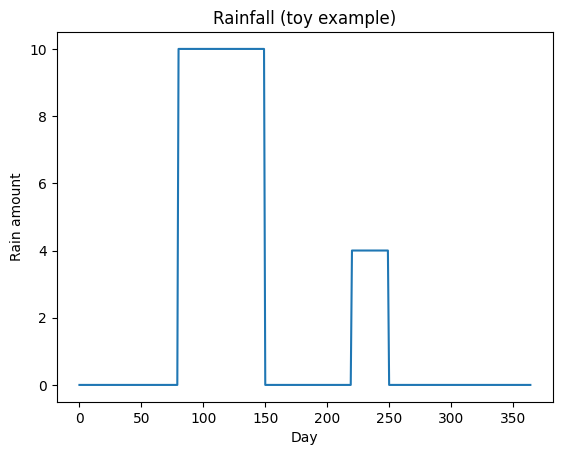

In [2]:
days = 365
rain = np.zeros(days)

# simple rainy season: day 80 to 150
rain[80:150] = 10

# a smaller rainy pulse later
rain[220:250] = 4

plt.figure()
plt.plot(rain)
plt.title("Rainfall (toy example)")
plt.xlabel("Day")
plt.ylabel("Rain amount")
plt.show()

Define mosquito ODE-like model (simple daily update rules)

In [3]:
def mosquito_step(Sv, Ev, Iv, rain_today, Ih, Nh, params):
    """
    One-day update for mosquito buckets.
    This is a 'discrete ODE' (daily step).
    """

    # unpack params
    mu = params["mu"]          # daily death fraction
    sigma = params["sigma"]    # fraction of Ev that becomes Iv per day
    b = params["b"]            # bites per mosquito per day
    p_hv = params["p_hv"]      # host->vector transmission chance per bite
    alpha = params["alpha"]    # how strongly rain creates new mosquitoes

    Nv = Sv + Ev + Iv
    if Nv < 1e-9:
        Nv = 1e-9

    # 1) Rain creates new adult mosquitoes (into Sv)
    emergence = alpha * (rain_today / (1 + rain_today))  # saturating effect
    Sv = Sv + emergence

    # 2) Healthy mosquitoes become infected if they bite infectious hosts
    # infection pressure from hosts:
    if Nh <= 0:
        lambda_v = 0
    else:
        lambda_v = b * p_hv * (Ih / Nh)   # "chance a mosquito gets infected today"
    new_Ev = lambda_v * Sv               # number moving Sv->Ev (simple)

    # cap so we don't move more than we have
    new_Ev = min(new_Ev, Sv)

    Sv = Sv - new_Ev
    Ev = Ev + new_Ev

    # 3) Exposed mosquitoes progress Ev->Iv
    prog = sigma * Ev
    prog = min(prog, Ev)
    Ev = Ev - prog
    Iv = Iv + prog

    # 4) Death applies to all mosquito groups
    Sv *= (1 - mu)
    Ev *= (1 - mu)
    Iv *= (1 - mu)

    # avoid negative due to rounding
    Sv = max(Sv, 0.0)
    Ev = max(Ev, 0.0)
    Iv = max(Iv, 0.0)

    return Sv, Ev, Iv

Define animal IBM (each animal has a state)

In [4]:
def init_hosts(n, init_I=0, seed=123):
    rng = np.random.default_rng(seed)
    states = np.array(["S"] * n, dtype="<U1")
    if init_I > 0:
        idx = rng.choice(n, size=min(init_I, n), replace=False)
        states[idx] = "I"
    days_in_state = np.zeros(n, dtype=int)
    return states, days_in_state

def host_progression(states, days_in_state, latent_days=3, infectious_days=5):
    """
    Move E->I after latent_days
    Move I->R after infectious_days
    """
    # increase counters for E and I
    mask = (states == "E") | (states == "I")
    days_in_state[mask] += 1

    # E->I
    to_I = (states == "E") & (days_in_state >= latent_days)
    states[to_I] = "I"
    days_in_state[to_I] = 0

    # I->R
    to_R = (states == "I") & (days_in_state >= infectious_days)
    states[to_R] = "R"
    days_in_state[to_R] = 0

    return states, days_in_state

def infect_hosts(states, days_in_state, lambda_h, rng):
    """
    Infect S hosts with daily probability p = 1 - exp(-lambda_h).
    Return number of new infections.
    """
    if lambda_h <= 0:
        return 0

    p = 1 - np.exp(-lambda_h)

    S_idx = np.where(states == "S")[0]
    if len(S_idx) == 0:
        return 0

    draws = rng.random(len(S_idx))
    newly = S_idx[draws < p]

    states[newly] = "E"
    days_in_state[newly] = 0
    return len(newly)

Define how mosquitoes infect animals (the “handshake”)

In [5]:
def lambda_host_from_vectors(Iv, Nh, params):
    """
    Simple infection pressure on hosts from infectious mosquitoes.
    Idea:
      total bites per day ~ b * (Sv+Ev+Iv)
      infectious bite fraction ~ Iv/Nv
    For simplicity: lambda_h proportional to Iv / Nh
    """
    b = params["b"]          # bites per mosquito per day
    p_vh = params["p_vh"]    # vector->host transmission chance per bite

    if Nh <= 0:
        return 0.0

    # simplest: lambda_h = (b * p_vh * Iv) / Nh
    return (b * p_vh * Iv) / Nh

Put parameters in one place

In [6]:
params = {
    # mosquito
    "mu": 0.10,      # 10% die daily (toy)
    "sigma": 0.20,   # 20% of exposed become infectious daily (toy)
    "b": 0.3,        # bites per mosquito per day
    "p_hv": 0.15,    # host->vector per bite prob
    "alpha": 80.0,   # rain -> new mosquitoes scaling

    # host infection
    "p_vh": 0.20,    # vector->host per bite prob
}

latent_days = 3
infectious_days = 5

Run ONE DAY manually (so you see what changes)

In [7]:
rng = np.random.default_rng(1)

# hosts
states, days_in_state = init_hosts(n=50, init_I=2, seed=1)

# mosquitoes
Sv, Ev, Iv = 500.0, 0.0, 0.0

day = 100
rain_today = rain[day]

Ih = np.sum(states == "I")
Nh = len(states)

print("Before day step:")
print("Rain:", rain_today, "Hosts I:", Ih, "Mosq Iv:", Iv)

# step mosquitoes
Sv, Ev, Iv = mosquito_step(Sv, Ev, Iv, rain_today, Ih, Nh, params)

# infection pressure hosts
lam_h = lambda_host_from_vectors(Iv, Nh, params)

# infect hosts
new_inf = infect_hosts(states, days_in_state, lam_h, rng)

# progress hosts
states, days_in_state = host_progression(states, days_in_state, latent_days, infectious_days)

print("\nAfter day step:")
print("New host infections today:", new_inf)
print("Host counts:", {k:int(np.sum(states==k)) for k in ["S","E","I","R"]})
print("Mosq counts:", {"Sv":Sv, "Ev":Ev, "Iv":Iv})
print("lambda_h:", lam_h)

Before day step:
Rain: 10.0 Hosts I: 2 Mosq Iv: 0.0

After day step:
New host infections today: 0
Host counts: {'S': 48, 'E': 0, 'I': 2, 'R': 0}
Mosq counts: {'Sv': np.float64(514.5267272727274), 'Ev': np.float64(0.7422545454545455), 'Iv': np.float64(0.1855636363636364)}
lambda_h: 0.0002226763636363637


Now run the full 365-day simulation

In [8]:
def simulate(days, rain, n_hosts=500, init_host_I=3,
             Sv0=800.0, Ev0=0.0, Iv0=0.0, seed=123):

    rng = np.random.default_rng(seed)

    states, days_in_state = init_hosts(n_hosts, init_I=init_host_I, seed=seed)
    Sv, Ev, Iv = Sv0, Ev0, Iv0

    # storage
    out = {
        "Sh": np.zeros(days, dtype=int),
        "Eh": np.zeros(days, dtype=int),
        "Ih": np.zeros(days, dtype=int),
        "Rh": np.zeros(days, dtype=int),
        "Sv": np.zeros(days, dtype=float),
        "Ev": np.zeros(days, dtype=float),
        "Iv": np.zeros(days, dtype=float),
        "new_inf_h": np.zeros(days, dtype=int),
        "rain": rain.copy()
    }

    for t in range(days):
        # counts from IBM
        Ih = int(np.sum(states == "I"))
        Nh = len(states)

        # ODE-like mosquitoes update
        Sv, Ev, Iv = mosquito_step(Sv, Ev, Iv, rain[t], Ih, Nh, params)

        # mosquitoes -> hosts force of infection
        lam_h = lambda_host_from_vectors(Iv, Nh, params)

        # new infections
        new_inf = infect_hosts(states, days_in_state, lam_h, rng)

        # progression
        states, days_in_state = host_progression(states, days_in_state, latent_days, infectious_days)

        # record
        out["Sh"][t] = np.sum(states == "S")
        out["Eh"][t] = np.sum(states == "E")
        out["Ih"][t] = np.sum(states == "I")
        out["Rh"][t] = np.sum(states == "R")

        out["Sv"][t] = Sv
        out["Ev"][t] = Ev
        out["Iv"][t] = Iv

        out["new_inf_h"][t] = new_inf

    return out

out = simulate(days=days, rain=rain, n_hosts=800, init_host_I=2)


Plot results (hosts and mosquitoes)

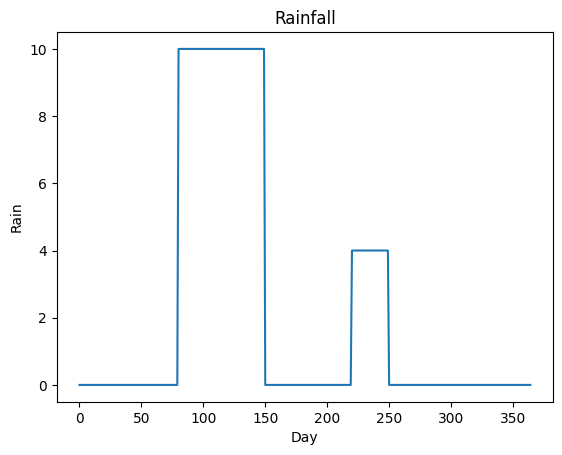

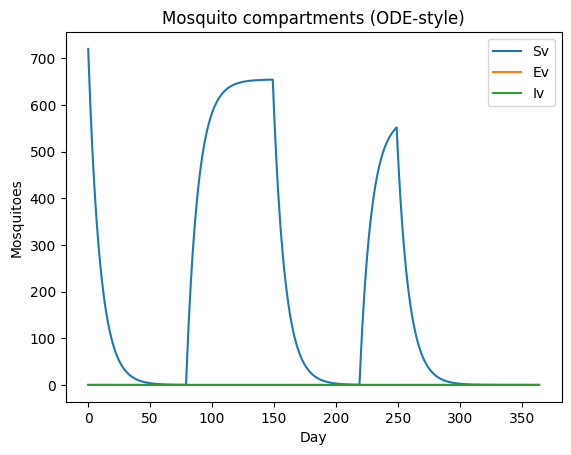

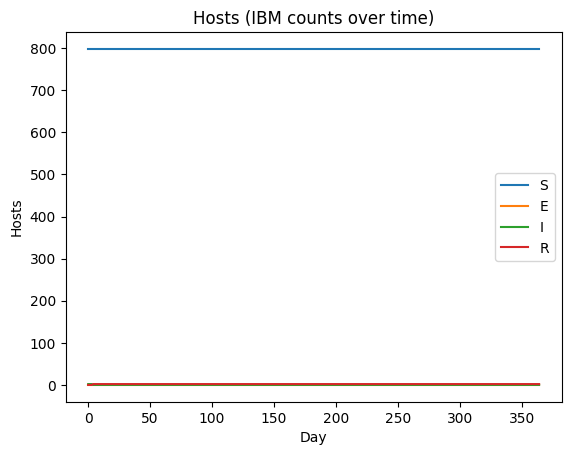

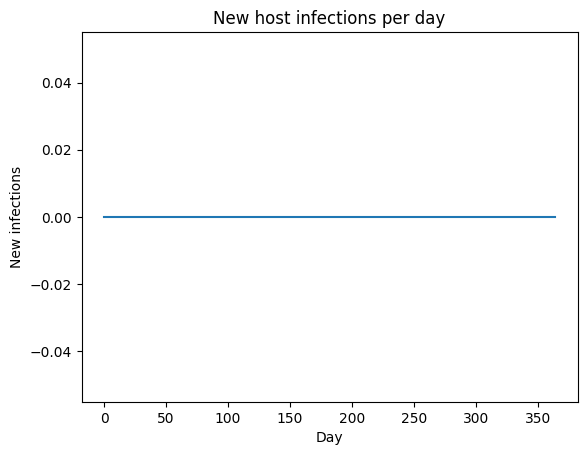

In [9]:
t = np.arange(days)

plt.figure()
plt.plot(t, out["rain"])
plt.title("Rainfall")
plt.xlabel("Day")
plt.ylabel("Rain")
plt.show()

plt.figure()
plt.plot(t, out["Sv"], label="Sv")
plt.plot(t, out["Ev"], label="Ev")
plt.plot(t, out["Iv"], label="Iv")
plt.title("Mosquito compartments (ODE-style)")
plt.xlabel("Day")
plt.ylabel("Mosquitoes")
plt.legend()
plt.show()

plt.figure()
plt.plot(t, out["Sh"], label="S")
plt.plot(t, out["Eh"], label="E")
plt.plot(t, out["Ih"], label="I")
plt.plot(t, out["Rh"], label="R")
plt.title("Hosts (IBM counts over time)")
plt.xlabel("Day")
plt.ylabel("Hosts")
plt.legend()
plt.show()

plt.figure()
plt.plot(t, out["new_inf_h"])
plt.title("New host infections per day")
plt.xlabel("Day")
plt.ylabel("New infections")
plt.show()

Put outputs into a table for inspection

In [10]:
df = pd.DataFrame({
    "day": np.arange(days),
    "rain": out["rain"],
    "Sv": out["Sv"],
    "Ev": out["Ev"],
    "Iv": out["Iv"],
    "Sh": out["Sh"],
    "Eh": out["Eh"],
    "Ih": out["Ih"],
    "Rh": out["Rh"],
    "new_inf_h": out["new_inf_h"],
})
df.head(10)

,day,rain,Sv,Ev,Iv,Sh,Eh,Ih,Rh,new_inf_h
0,0,0.0,719.919000,0.064800,0.016200,798,0,2,0,0
1,1,0.0,647.854208,0.104969,0.040822,798,0,2,0,0
2,2,0.0,583.003192,0.128054,0.068754,798,0,2,0,0
3,3,0.0,524.643844,0.139422,0.096734,798,0,2,0,0
4,4,0.0,472.126339,0.142880,0.122781,798,0,0,2,0
5,5,0.0,424.913705,0.102874,0.136221,798,0,0,2,0
6,6,0.0,382.422335,0.074069,0.141116,798,0,0,2,0
7,7,0.0,344.180101,0.053330,0.140337,798,0,0,2,0
8,8,0.0,309.762091,0.038397,0.135903,798,0,0,2,0
9,9,0.0,278.785882,0.027646,0.129224,798,0,0,2,0


In [11]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1vBs_5XEnSIwUbxGe-cFfuIgYEHILUvTTELqV0snbbi8/edit#gid=0
